# yfinance Exploratory Data Analysis

In [5]:
# Imports
import yfinance as yf
import pandas as pd
import requests
from io import StringIO
from IPython.display import clear_output
import os

## Accessing Stock Data

In [5]:
# Function to fetch stock data for a single ticker using specified start and end dates
def get_stock_data_using_dates(ticker, start_date, end_date, interval="1d"):
    try:
        stock_data = yf.Ticker(ticker).history(start=start_date, end=end_date, interval=interval)
        return stock_data
    except Exception as e:
        print(f"An error occurred while fetching stock data: {e}")
        return None

# Function to fetch stock data for a single ticker using a specified period
def get_stock_data_using_period(ticker, period, interval="1d"):
    try:
        stock_data = yf.Ticker(ticker).history(period=period, interval=interval)
        return stock_data
    except Exception as e:
        print(f"An error occurred while fetching stock data: {e}")
        return None

# Function to fetch the list of S&P 500 companies from Wikipedia
def get_snp_companies():
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    table = pd.read_html(StringIO(response.text))[0]

    snp_df = table[["Symbol", "Security", "GICS Sector", "Date added"]].copy()
    snp_df["Symbol"] = snp_df["Symbol"].str.replace(".", "-", regex=False)

    return snp_df

# Example usage:
if __name__ == "__main__":
    import time

    stock_data_dates = get_stock_data_using_dates("TSLA", "2023-01-01", "2023-12-31")
    if stock_data_dates is not None:
        print(stock_data_dates.head())
    else:
        print("Still rate limited — wait a minute and try again.")

    time.sleep(60)  

    stock_data_period = get_stock_data_using_period("TSLA", "max")

    snp_companies = get_snp_companies()
    snp_companies.to_csv("../raw_data/snp_companies.csv", index=False)

/opt/anaconda3/lib/python3.12/site-packages/yfinance/scrapers/history.py:169: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


An error occurred while fetching stock data: Too Many Requests. Rate limited. Try after a while.
Still rate limited — wait a minute and try again.
An error occurred while fetching stock data: Too Many Requests. Rate limited. Try after a while.


## Preprocessing a Single Stock

Notes:
1. Open/Close is already adjusted for Stock Splits

In [6]:
tsla_history = get_stock_data_using_period("TSLA", "max")
tsla_history.to_csv("../raw_data/tsla_stock_data.csv")

# Add daily returns, moving averages, and volatility as technical features
def add_technical_features(df):
    df = df.copy()

    # Daily returns based off closing prices
    df["Return_1D"] = df["Close"].pct_change()

    # Moving averages based off closing prices
    df["MA_5"] = df["Close"].rolling(5).mean()
    df["MA_21"] = df["Close"].rolling(21).mean()
    df["MA_126"] = df["Close"].rolling(126).mean()
    df["MA_252"] = df["Close"].rolling(252).mean()

    # Volatility (standard deviation of returns) based off daily returns
    df["Volatility_21"] = df["Return_1D"].rolling(21).std()

    # Drop rows with NaN values resulting from rolling calculations
    df.dropna(inplace=True)

    # Remove Dividend and Stock Splits columns as they are not needed for modeling
    df.drop(columns=["Dividends", "Stock Splits"], inplace=True)

    return df

tsla_history_with_features = add_technical_features(tsla_history)
tsla_history_with_features.to_csv("../raw_data/tsla_stock_data_with_features.csv", index=True)

/opt/anaconda3/lib/python3.12/site-packages/yfinance/scrapers/history.py:169: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


An error occurred while fetching stock data: Too Many Requests. Rate limited. Try after a while.


AttributeError: 'NoneType' object has no attribute 'to_csv'

## Get all Preprocessed Data for Numerous/All Stocks in the SNP 500

In [81]:
# Option 1 : Get all tickers from raw/snp_companies.csv
# NOTE: This will result in 1GB of data being fetched and stored in processed_data
# If you want to fetch data for a smaller subset of tickers, you can modify the code below to only include a few tickers from the list.
snp_companies_df = pd.read_csv("../raw_data/snp_companies.csv")
#tickers = snp_companies_df["Symbol"].tolist()

# Option 2: Fetch data for a smaller subset of tickers
tickers = ["NVDA","AAPL","MSFT","AMZN","GOOGL","AVGO","META","GOOG","TSLA","BRK-B"]  # Example subset of tickers

# Fetch stock data using max period for all tickers
total_tickers = len(tickers)

for i, ticker in enumerate(tickers, start=1):
    stock_data_max_period = get_stock_data_using_period(ticker, period="max")
    preprocessed_data = add_technical_features(stock_data_max_period)
    preprocessed_data.to_csv(f"../processed_data/stock_data/{ticker}_stock_data.csv", index=True)

    stock_recommendations = yf.Ticker(ticker).get_recommendations()
    stock_recommendations.to_csv(f"../processed_data/recommendations/{ticker}_recommendations.csv", index=True)

    clear_output(wait=True)
    print(f"Fetched data for {ticker} ({i}/{total_tickers}). Progress: {i/total_tickers:.2%}")

Fetched data for BRK-B (10/10). Progress: 100.00%


## Visualization 

In [7]:
import pandas as pd

tsla = pd.read_csv("../processed_data/stock_data/TSLA_stock_data.csv")
print(tsla.head())

                        Date      Open      High       Low     Close  \
0  2011-06-27 00:00:00-04:00  1.848667  1.885333  1.820667  1.830667   
1  2011-06-28 00:00:00-04:00  1.852667  1.883333  1.844667  1.874000   
2  2011-06-29 00:00:00-04:00  1.900000  1.939333  1.871333  1.886000   
3  2011-06-30 00:00:00-04:00  1.900000  1.955333  1.893333  1.942000   
4  2011-07-01 00:00:00-04:00  1.938000  1.973333  1.920000  1.934667   

     Volume  Return_1D      MA_5     MA_21    MA_126    MA_252  Volatility_21  
0  27141000  -0.003990  1.833067  1.865428  1.714222  1.631495       0.029851  
1  13338000   0.023671  1.840800  1.860857  1.715122  1.632611       0.030398  
2  21927000   0.006403  1.855200  1.854984  1.715418  1.633791       0.030051  
3  14200500   0.029692  1.874133  1.856921  1.716810  1.635688       0.028419  
4  12823500  -0.003776  1.893467  1.857746  1.718074  1.638286       0.028393  


In [22]:
import pandas as pd

tickers = ["AAPL", "TSLA", "NVDA", "MSFT","AMZN","GOOGL", "META"]
data = {}

for t in tickers:
    path = f"../processed_data/stock_data/{t}_stock_data.csv"
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], utc=True)  # handles timezone aware dates
    df["Ticker"] = t
    data[t] = df

combined = pd.concat(data.values())
print(combined.head(20))

                        Date      Open      High       Low     Close  \
0  1981-12-10 05:00:00+00:00  0.064534  0.064962  0.064534  0.064534   
1  1981-12-11 05:00:00+00:00  0.064534  0.064962  0.064107  0.064107   
2  1981-12-14 05:00:00+00:00  0.062825  0.062825  0.061970  0.061970   
3  1981-12-15 05:00:00+00:00  0.063680  0.064107  0.063680  0.063680   
4  1981-12-16 05:00:00+00:00  0.066672  0.067099  0.066672  0.066672   
5  1981-12-17 05:00:00+00:00  0.072227  0.072655  0.072227  0.072227   
6  1981-12-18 05:00:00+00:00  0.078211  0.078638  0.078211  0.078211   
7  1981-12-21 05:00:00+00:00  0.075219  0.075219  0.074792  0.074792   
8  1981-12-22 05:00:00+00:00  0.076074  0.076501  0.076074  0.076074   
9  1981-12-23 05:00:00+00:00  0.074792  0.074792  0.074364  0.074364   
10 1981-12-24 05:00:00+00:00  0.074792  0.075219  0.074792  0.074792   
11 1981-12-28 05:00:00+00:00  0.072227  0.072227  0.071373  0.071373   
12 1981-12-29 05:00:00+00:00  0.072655  0.073509  0.072655  0.07

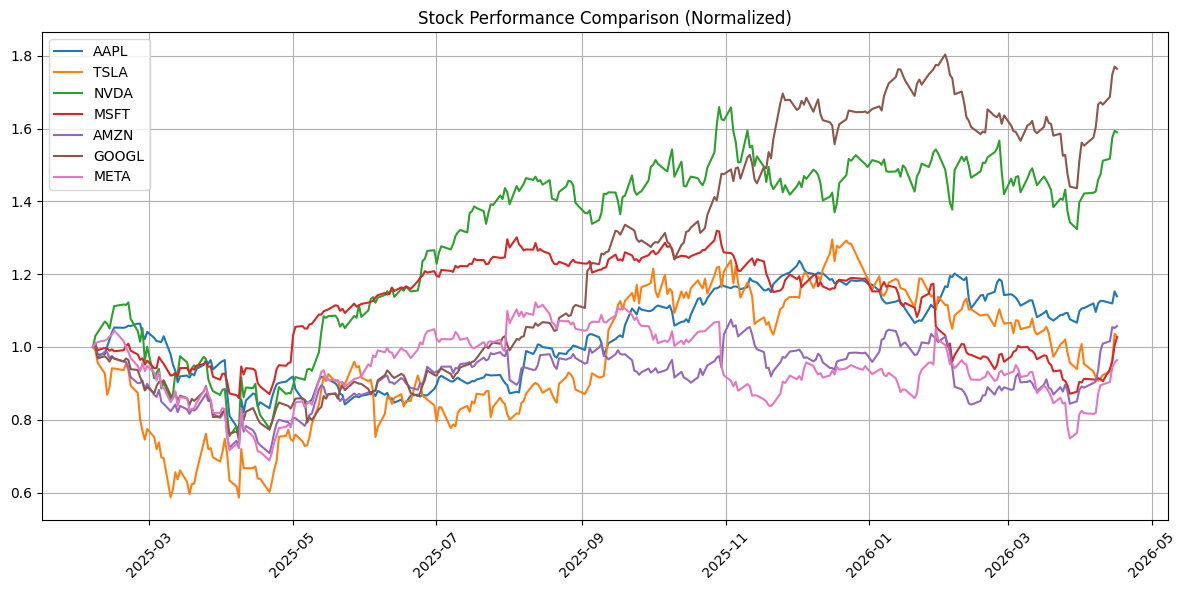

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for t in tickers:
    df = data[t].tail(300)  # last year
    
    # normalize (start all at 1)
    df["Normalized"] = df["Close"] / df["Close"].iloc[0]
    
    plt.plot(df["Date"], df["Normalized"], label=t)

plt.legend()
plt.title("Stock Performance Comparison (Normalized)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Google performed the best overall, while AAPL showed steady and consistent growth. MSFT increased at first but then lost some of those gains, and TSLA was the most unpredictable, with a big drop early on and only a partial recovery. For our project, this chart helps compare how each stock behaves over time, especially in terms of growth and volatility. It suggests that stocks don’t all react the same way to outside factors like news more volatile stocks like Tesla may respond more strongly to news, while more stable stocks like Apple may not change as much in the short term

In [26]:
for t in tickers:
    path = f"../processed_data/stock_data/{t}_stock_data.csv"
    df = pd.read_csv(path, index_col="Date", parse_dates=True)
    df.index = pd.to_datetime(df.index, utc=True)
    df["Ticker"] = t
    data[t] = df

combined = pd.concat(data.values())

In [28]:
for ticker in tickers:
    df = combined[combined["Ticker"] == ticker]
    print(f"{ticker}: {df.index.min()} → {df.index.max()}")

AAPL: 1981-12-10 05:00:00+00:00 → 2026-04-16 04:00:00+00:00
TSLA: 2011-06-27 04:00:00+00:00 → 2026-04-16 04:00:00+00:00
NVDA: 2000-01-20 05:00:00+00:00 → 2026-04-16 04:00:00+00:00
MSFT: 1987-03-11 05:00:00+00:00 → 2026-04-16 04:00:00+00:00
AMZN: 1998-05-14 04:00:00+00:00 → 2026-04-16 04:00:00+00:00
GOOGL: 2005-08-17 04:00:00+00:00 → 2026-04-16 04:00:00+00:00
META: 2013-05-21 04:00:00+00:00 → 2026-04-16 04:00:00+00:00


In [30]:
# analyzing data from last year. I thought recent data would align more  with whats happening now
combined = combined[combined.index >= "2025-04-16"]


In [32]:
features = ["Return_1D", "MA_5", "MA_21", "MA_126", "MA_252", "Volatility_21", "Close"]

stats = combined.groupby("Ticker")[features].agg([
    "mean", "std", "min", "max"
]).round(4)

print(stats)

       Return_1D                              MA_5                     \
            mean     std     min     max      mean      std       min   
Ticker                                                                  
AAPL      0.0012  0.0150 -0.0500  0.0631  240.9395  27.7726  196.4020   
AMZN      0.0015  0.0199 -0.0827  0.0958  220.0010  15.2458  173.4060   
GOOGL     0.0032  0.0181 -0.0726  0.0914  248.4526  61.9643  151.2715   
META      0.0013  0.0225 -0.1133  0.1125  669.5569  62.9415  500.2394   
MSFT      0.0005  0.0156 -0.0999  0.0763  465.0997  48.8985  364.2480   
NVDA      0.0025  0.0220 -0.0687  0.0787  170.3794  23.6459  100.8742   
TSLA      0.0022  0.0310 -0.1426  0.0980  379.6807  59.7556  239.8260   

                     MA_21           ...    MA_252           Volatility_21  \
             max      mean      std  ...       min       max          mean   
Ticker                               ...                                     
AAPL    282.3338  239.2045  27.9015

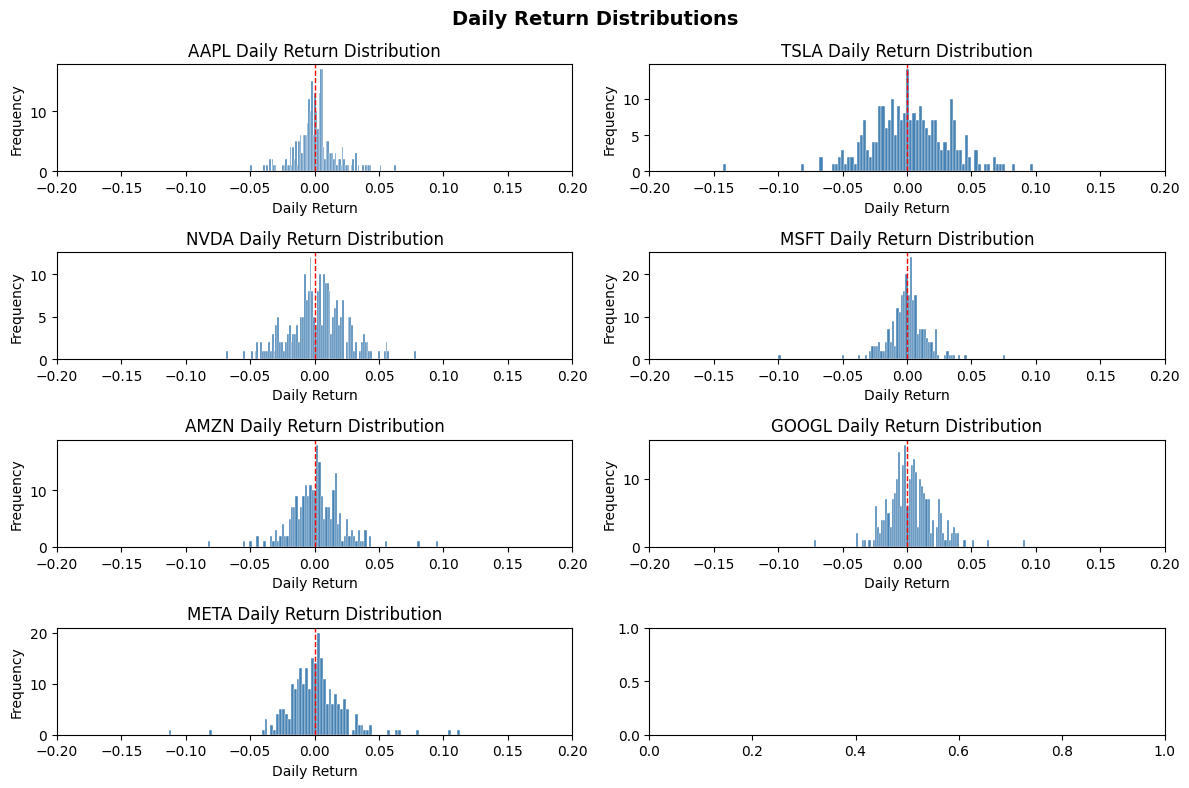

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(12, 8))
axes = axes.flatten()

tickers = combined["Ticker"].unique()

for i, ticker in enumerate(tickers):
    df = combined[combined["Ticker"] == ticker]
    axes[i].hist(df["Return_1D"], bins=100, color="steelblue", edgecolor="white", linewidth=0.3)
    axes[i].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(f"{ticker} Daily Return Distribution")
    axes[i].set_xlabel("Daily Return")
    axes[i].set_ylabel("Frequency")
    axes[i].set_xlim(-0.2, 0.2)  # adjust if TSLA/NVDA have more extreme swings

plt.suptitle("Daily Return Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

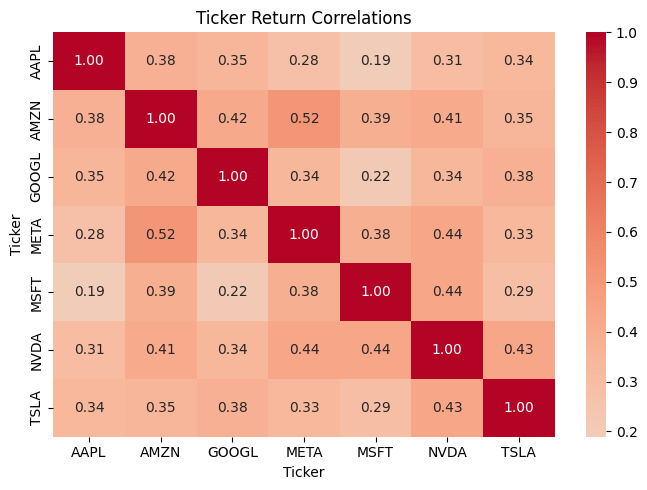

In [34]:
import seaborn as sns

# Pivot so each column is a ticker's daily return
returns_pivot = combined.pivot_table(index="Date", columns="Ticker", values="Return_1D")

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    returns_pivot.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax
)
ax.set_title("Ticker Return Correlations")
plt.tight_layout()
plt.show()

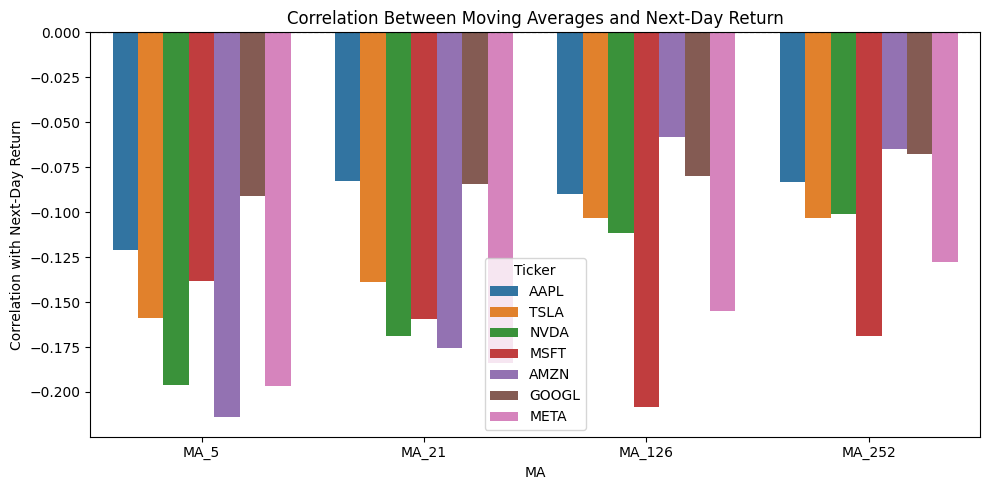

In [42]:
# For each ticker, check correlation between MAs and NEXT day's return
results = []

for ticker in combined["Ticker"].unique():
    df = combined[combined["Ticker"] == ticker].copy()
    df["Next_Return"] = df["Return_1D"].shift(-1)  # tomorrow's return
    
    for ma in ["MA_5", "MA_21", "MA_126", "MA_252"]:
        corr = df[ma].corr(df["Next_Return"])
        results.append({"Ticker": ticker, "MA": ma, "Correlation": corr})

results_df = pd.DataFrame(results)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=results_df, x="MA", y="Correlation", hue="Ticker", ax=ax)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Correlation Between Moving Averages and Next-Day Return")
ax.set_ylabel("Correlation with Next-Day Return")
plt.tight_layout()
plt.show()

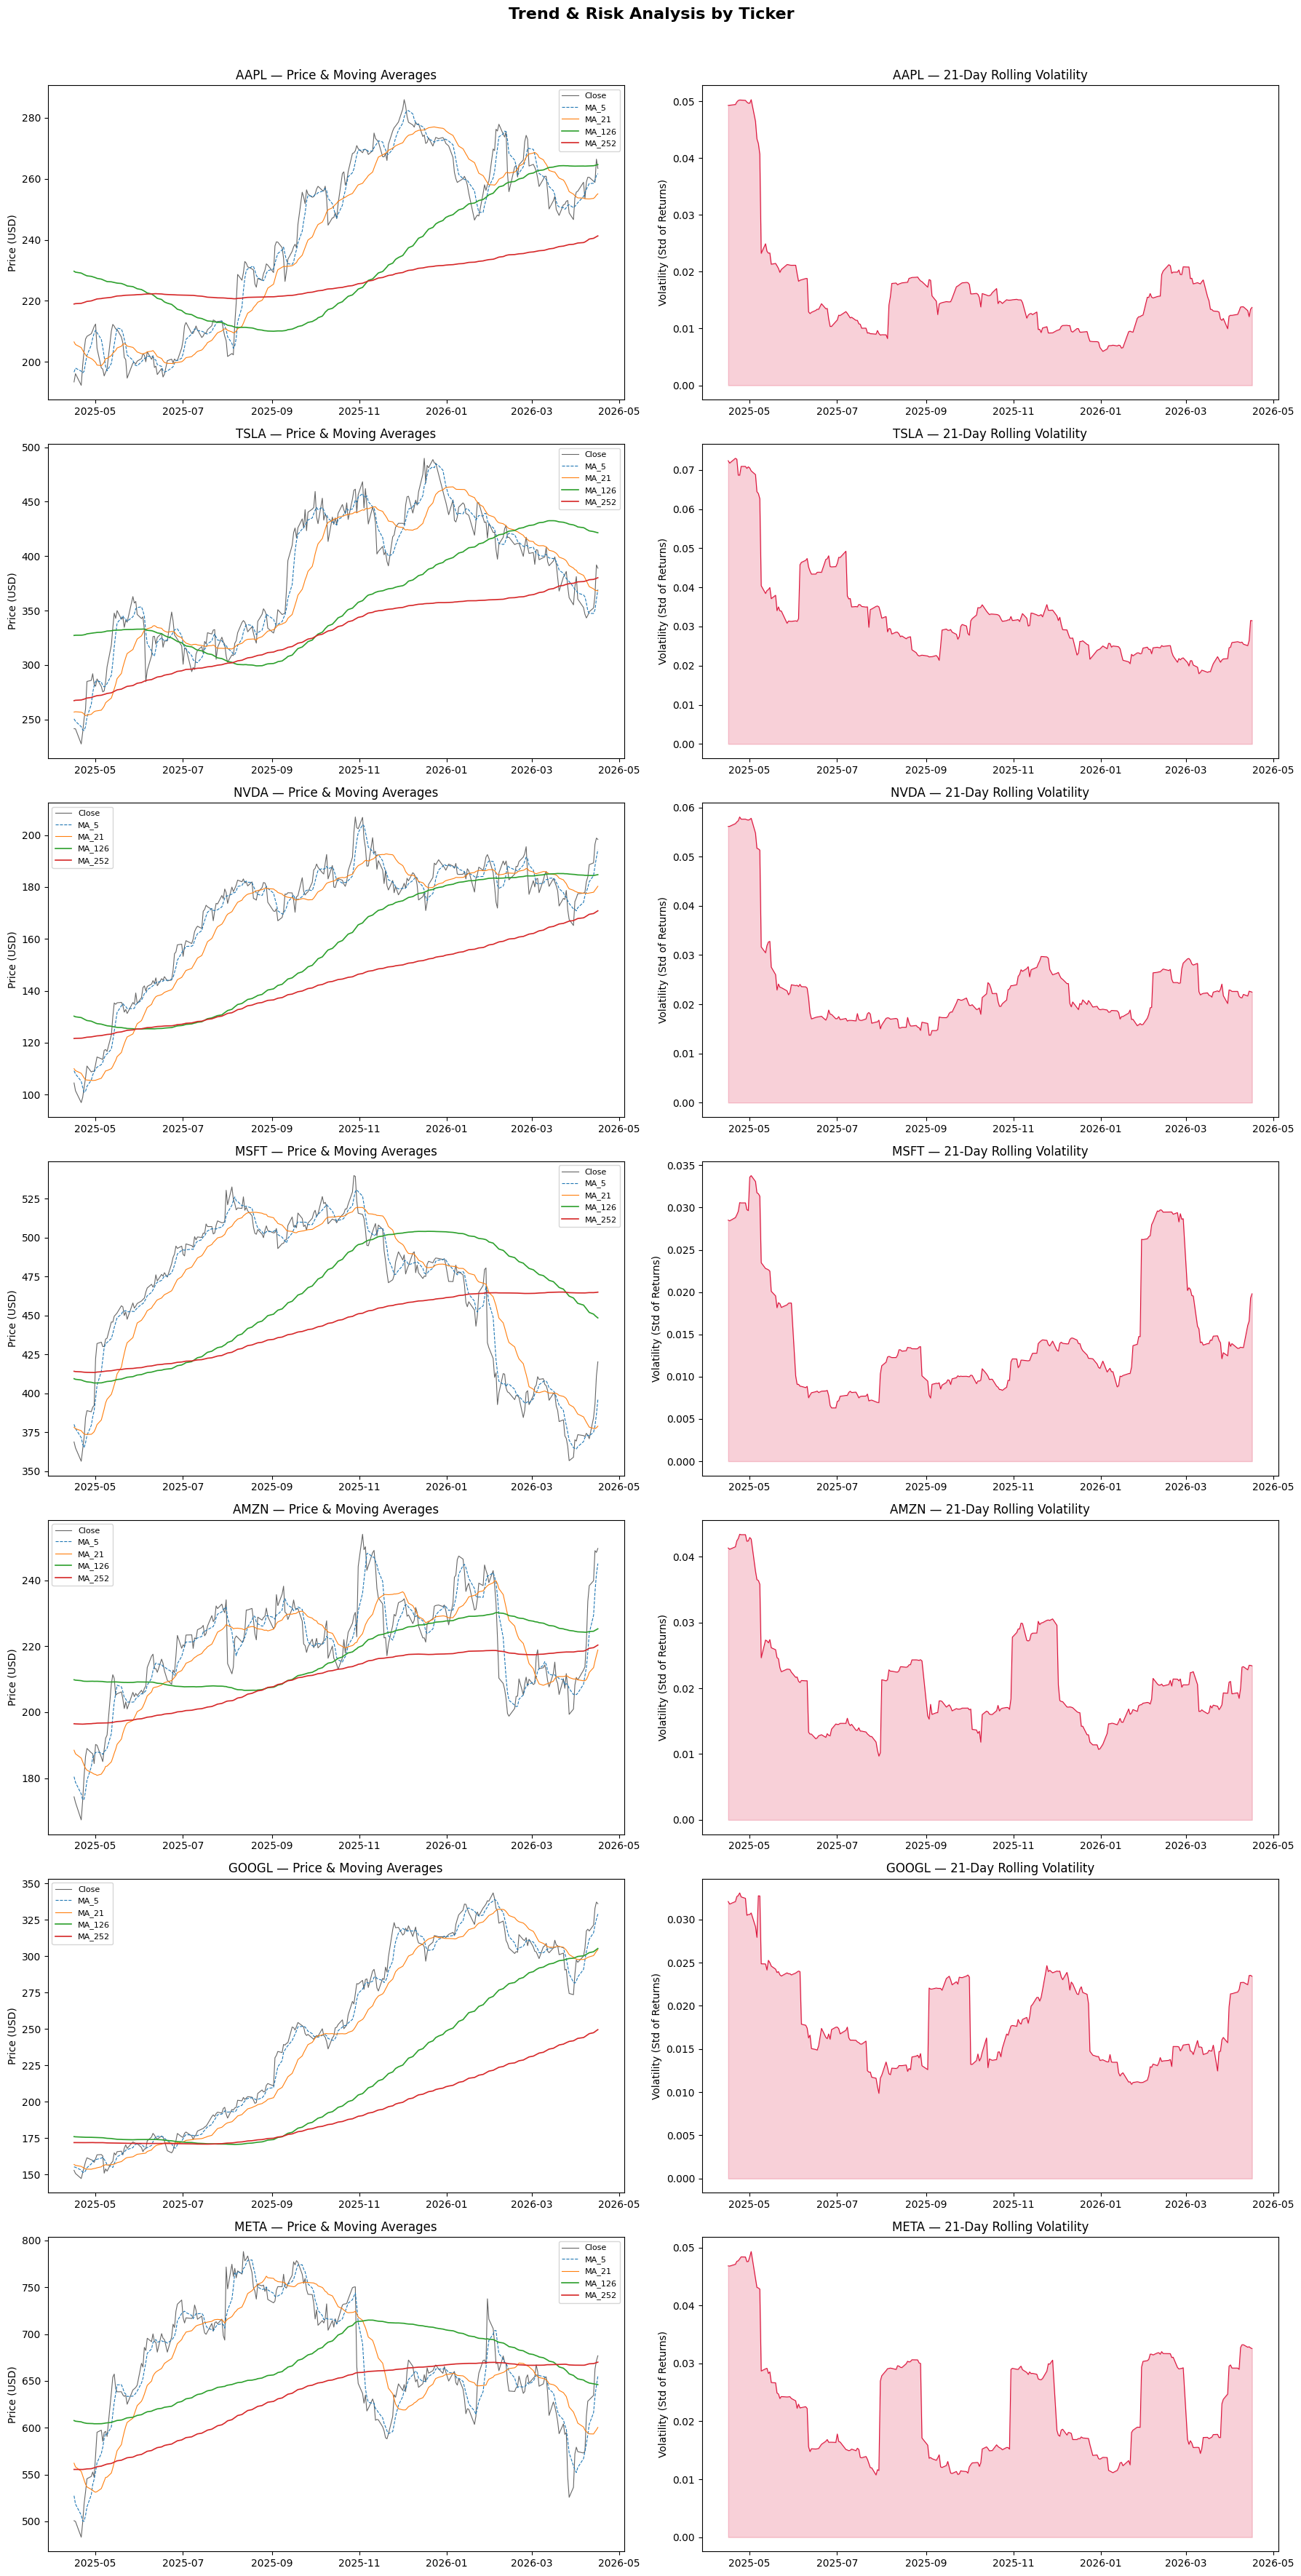

In [50]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(18, 5 * len(tickers)))

for i, ticker in enumerate(tickers):
    df = combined[combined["Ticker"] == ticker].copy().sort_index()

    #Left: Price + Moving Averages
    ax1 = axes[i, 0]
    ax1.plot(df.index, df["Close"], color="black", linewidth=0.8, label="Close", alpha=0.6)
    ax1.plot(df.index, df["MA_5"],   linewidth=0.8, label="MA_5",   linestyle="--")
    ax1.plot(df.index, df["MA_21"],  linewidth=0.8, label="MA_21")
    ax1.plot(df.index, df["MA_126"], linewidth=1.2, label="MA_126")
    ax1.plot(df.index, df["MA_252"], linewidth=1.2, label="MA_252")
    ax1.set_title(f"{ticker} — Price & Moving Averages")
    ax1.set_ylabel("Price (USD)")
    ax1.legend(fontsize=8)

    # Right: Volatility 
    ax2 = axes[i, 1]
    ax2.plot(df.index, df["Volatility_21"], color="crimson", linewidth=0.8)
    ax2.fill_between(df.index, df["Volatility_21"], alpha=0.2, color="crimson")
    ax2.set_title(f"{ticker} — 21-Day Rolling Volatility")
    ax2.set_ylabel("Volatility (Std of Returns)")

plt.suptitle("Trend & Risk Analysis by Ticker", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()